In [748]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
import pdb

In [749]:
# for .mat files saved in MATLAB v7.2 or earlier (most common)
data = sio.loadmat('/Users/avinashranjan/Desktop/UT Austin/Goris lab/Model_V1_damage/V1DamageModel/SpikeData.mat', simplify_cells=True)
dataTest = sio.loadmat('/Users/avinashranjan/Desktop/UT Austin/Goris lab/Model_V1_damage/V1DamageModel/SpikeDataTest.mat', simplify_cells=True)

# print(data['data'].keys())   # see what variables are inside

In [750]:
# ── Data structures for training ─────────────────────────────────────────────────────────────────
spikeData      = data['data']['spikesIntactV1']
tralStimVector = data['data']['trlStimVector']

tralStimVector = np.rad2deg(tralStimVector)
correctLabels  = (tralStimVector > 90).astype(int)

spikes = np.zeros((len(spikeData), len(spikeData[1]), len(spikeData[1][1])))
for i in range(len(spikeData)):
    _spkData = spikeData[i]
    spikes[i, :, :] = _spkData.T

# Data structure to use
spikes = spikes.astype(int) # ntrials x ntimePoints x nNeurons
labels = correctLabels

# spikes = spikes[1:100, :, :]
# labels = labels[1:100]

# make sure shapes are correct
spikes = spikes.astype(np.float32)   # (4000, 200, 200)
labels = labels.astype(np.float32).squeeze()  # (4000,)

print(spikes.shape, labels.shape)
print(np.unique(labels))   # should be [0, 1]

# ── to tensors ────────────────────────────────────────────────────────────────
X = torch.tensor(spikes)   # (4000, 200, 200)
Y = torch.tensor(labels)   # (4000,)

(4200, 200, 200) (4200,)
[0. 1.]


In [751]:
# ── model ─────────────────────────────────────────────────────────────────────
class DecisionRNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.rnn    = nn.RNN(input_size, hidden_size,
                              nonlinearity='tanh', batch_first=True)
        
        # readout heads
        self.w_dec  = nn.Linear(hidden_size, 1) # Decision readout
        self.w_conf = nn.Linear(hidden_size, 1) # Confidence readout

        # initialise weights
        nn.init.orthogonal_(self.rnn.weight_hh_l0)

        # small uniform init for readout heads
        nn.init.uniform_(self.w_dec.weight,  -0.1, 0.1)
        nn.init.uniform_(self.w_conf.weight, -0.1, 0.1)
        
    def forward(self, x):
        """
        x : (batch, T, N_neurons)

        Returns
        -------
        z_dec  : (batch,)   decision logit
        z_conf : (batch,)   confidence logit
        h      : (batch, T, hidden)  full hidden trajectory (for analysis)
        """
        h, _   = self.rnn(x)
        h_T    = h[:, -1, :]
        z_dec  = self.w_dec(h_T).squeeze(-1)
        z_conf = self.w_conf(h_T).squeeze(-1)
        return z_dec, z_conf, h


In [752]:
model     = DecisionRNN(input_size=200, hidden_size=20) # 20 hideen size nice, epoch 20
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [753]:
# ── training loop ─────────────────────────────────────────────────────────────
n_epochs   = 40
batch_size = 64
n_trials   = len(Y)

for epoch in range(n_epochs):
    
    # shuffle each epoch
    perm     = torch.randperm(n_trials)
    X_, Y_   = X[perm], Y[perm]
    
    epoch_loss = 0
    n_correct  = 0

    for i in range(0, n_trials, batch_size):
        x_batch = X_[i : i+batch_size]
        y_batch = Y_[i : i+batch_size]
        
        optimizer.zero_grad()

        z_dec, z_conf, h = model(x_batch)

        # choice loss
        p_choice = torch.where(z_dec > 0, torch.sigmoid(z_dec), 1 - torch.sigmoid(z_dec))
        L_choice = F.binary_cross_entropy_with_logits(z_dec, y_batch)

        # brier loss
        with torch.no_grad():
            #c_target = torch.sigmoid(2.0 * z_dec.abs())
            correct = ((z_dec > 0).float() == y_batch).float()
            lossWeights = torch.where(correct == 1, 18.8, 18.8)
        c_hat    = torch.sigmoid(z_conf)
        L_conf   = torch.mean(lossWeights * ( (correct - c_hat)**2 )) #F.mse_loss(c_hat, correct)

        #c_hat  = torch.sigmoid(z_conf)
        #L_conf = F.mse_loss(c_hat, c_target)

        #someVar  = torch.where(correct == 1, p_choice, 1 - p_choice) # extract signal strength
        #L_conf   = torch.mean( lossWeights * (someVar - c_hat)**2 )
        
        # Choice loss - take signal strength into account
        #L_choice = F.mse_loss(p_choice, correct)
        
        #L_z_reg   = z_dec.pow(2).mean()    # penalise large |z_dec|
        
        loss = L_choice + L_conf # 20, 100*L_conf + L_z_reg % change score - lc and hc should probably be treated differently
        loss.backward() # compute gradient
        nn.utils.clip_grad_norm_(model.parameters(), 1.0) # normalize gradients
        optimizer.step() # Update weights
        
        epoch_loss += loss.item()
        n_correct  += ((z_dec > 0).float() == y_batch).sum().item()

    acc = n_correct / n_trials
    print(f"Epoch {epoch+1:3d} | loss: {epoch_loss:.4f} | acc: {acc:.3f}")


Epoch   1 | loss: 354.2857 | acc: 0.511
Epoch   2 | loss: 334.6840 | acc: 0.626
Epoch   3 | loss: 293.8940 | acc: 0.722
Epoch   4 | loss: 261.4419 | acc: 0.760
Epoch   5 | loss: 242.1991 | acc: 0.780
Epoch   6 | loss: 225.3236 | acc: 0.794
Epoch   7 | loss: 211.9112 | acc: 0.803
Epoch   8 | loss: 205.4298 | acc: 0.805
Epoch   9 | loss: 204.0232 | acc: 0.803
Epoch  10 | loss: 197.2557 | acc: 0.806
Epoch  11 | loss: 193.3545 | acc: 0.805
Epoch  12 | loss: 188.9375 | acc: 0.810
Epoch  13 | loss: 187.1322 | acc: 0.807
Epoch  14 | loss: 186.0440 | acc: 0.815
Epoch  15 | loss: 181.0319 | acc: 0.812
Epoch  16 | loss: 175.0870 | acc: 0.814
Epoch  17 | loss: 174.7204 | acc: 0.816
Epoch  18 | loss: 172.0569 | acc: 0.818
Epoch  19 | loss: 168.9876 | acc: 0.817
Epoch  20 | loss: 165.7505 | acc: 0.819
Epoch  21 | loss: 164.2408 | acc: 0.814
Epoch  22 | loss: 161.3801 | acc: 0.818
Epoch  23 | loss: 158.4069 | acc: 0.819
Epoch  24 | loss: 158.7311 | acc: 0.820
Epoch  25 | loss: 158.1181 | acc: 0.828


In [754]:
# ── Evaluate model ───────────────────────────────────────────────────────────
model.eval()   # turns off dropout etc. (good habit even if you don't have them)

with torch.no_grad():   # no gradient computation needed
    z_dec, z_conf, h = model(X)

# ── convert to numpy ──────────────────────────────────────────────────────────
z_dec  = z_dec.numpy()            # (4000,)  raw decision variable
z_conf = z_conf.numpy()           # (4000,)  raw confidence variable

choice     = (z_dec > 0).astype(float)      # (4000,)  binary decision {0,1}
confidence = torch.sigmoid(torch.tensor(z_conf)).numpy()  # (4000,)  in [0,1]

print(z_dec.shape, confidence.shape)
print(f"Mean confidence: {confidence.mean():.3f}")
print(f"Overall accuracy: {(choice == Y.numpy()).mean():.3f}")

(4200,) (4200,)
Mean confidence: 0.822
Overall accuracy: 0.842


In [755]:
# ── Load test data ───────────────────────────────────────────────────────────
spikeData      = dataTest['dataTest']['spikesIntactV1Test']
tralStimVector = data['data']['trlStimVector']

tralStimVector = np.rad2deg(tralStimVector)
correctLabels  = (tralStimVector > 90).astype(int)

spikes = np.zeros((len(spikeData), len(spikeData[1]), len(spikeData[1][1])))
for i in range(len(spikeData)):
    _spkData = spikeData[i]
    spikes[i, :, :] = _spkData.T

# Data structure to use
spikes = spikes.astype(int) # ntrials x ntimePoints x nNeurons
labels = correctLabels

# spikes = spikes[1:100, :, :]
# labels = labels[1:100]

# make sure shapes are correct
spikes = spikes.astype(np.float32)   # (4000, 200, 200)
labels = labels.astype(np.float32).squeeze()  # (4000,)

print(spikes.shape, labels.shape)
print(np.unique(labels))   # should be [0, 1]

# ── to tensors ────────────────────────────────────────────────────────────────
X = torch.tensor(spikes)   # (4000, 200, 200)
Y = torch.tensor(labels)   # (4000,)

(4200, 200, 200) (4200,)
[0. 1.]


In [756]:
# ── Evaluate model ───────────────────────────────────────────────────────────
model.eval()   # turns off dropout etc. (good habit even if you don't have them)

with torch.no_grad():   # no gradient computation needed
    z_dec, z_conf, h = model(X)

# ── convert to numpy ──────────────────────────────────────────────────────────
p_conf = torch.sigmoid(z_conf).numpy()  # (4000,)  in [0,1]
z_dec  = z_dec.numpy()            # (4000,)  raw decision variable
z_conf = z_conf.numpy()           # (4000,)  raw confidence variable

choice     = (z_dec > 0).astype(float)      # (4000,)  binary decision {0,1}
confidence = torch.sigmoid(torch.tensor(z_conf)).numpy()  # (4000,)  in [0,1]
Cc         = np.median(confidence)

print(z_dec.shape, confidence.shape)
print(f"Mean confidence: {confidence.mean():.3f}")
print(f"Prop HC: {(confidence > Cc).sum()/len(confidence):.3f}") # Is probability of correct bounded by 0.5?
print(f"Overall accuracy: {(choice == Y.numpy()).mean():.3f}")

# Ground truth
# Decision accuracy: 78%
# Prop HC: 50%

(4200,) (4200,)
Mean confidence: 0.819
Prop HC: 0.500
Overall accuracy: 0.786


In [757]:
# ── Psychometric curve and confidence curve ───────────────────────────────────────────────────────────
uniqStimOris = np.rad2deg(data['data']['uniqStimOris'])

confFn       = np.zeros([1, len(uniqStimOris)])
psycFns      = np.zeros([3, len(uniqStimOris)]) # Combined, HC, LC
choiceCounts = np.zeros([4, len(uniqStimOris)]);

for i in range(len(uniqStimOris)):
    ori = uniqStimOris[i]
    fltIdx = tralStimVector == ori

    fltRNNDecisions = choice[fltIdx]
    fltRNNConf      = confidence[fltIdx]

    # Confidence function
    #confFn[0, i]  = np.mean(fltRNNConf) # Mean confidence level
    confFn[0, i]  = (fltRNNConf > Cc).sum() / len(fltRNNConf) # P(HC)
    
    # Psychometric function
    percent_CW    = (fltRNNDecisions == 1).astype(int).sum()/ len(fltRNNDecisions)
    psycFns[0, i] = percent_CW; 

    percent_CW_HC = ( (fltRNNDecisions == 1) & (fltRNNConf > Cc) ).astype(int).sum() / (fltRNNConf > Cc).astype(int).sum()
    percent_CW_LC = ( (fltRNNDecisions == 1) & (fltRNNConf <= Cc) ).astype(int).sum() / (fltRNNConf <= Cc).astype(int).sum()
    psycFns[1, i] = percent_CW_HC
    psycFns[2, i] = percent_CW_LC

    choiceCounts[0, i] = ( (fltRNNDecisions == 1) & (fltRNNConf > Cc) ).sum() / (fltRNNDecisions).sum() #(CW, HC)
    choiceCounts[1, i] = ( (fltRNNDecisions == 1) & (fltRNNConf <= Cc) ).sum() / (fltRNNDecisions).sum() #(CW, LC)
    choiceCounts[2, i] = ( (fltRNNDecisions == 0) & (fltRNNConf > Cc) ).sum() / (fltRNNDecisions).sum();  #(CCW, HC)
    choiceCounts[3, i] = ( (fltRNNDecisions == 0) & (fltRNNConf <= Cc) ).sum() / (fltRNNDecisions).sum(); #(CCW, LC)


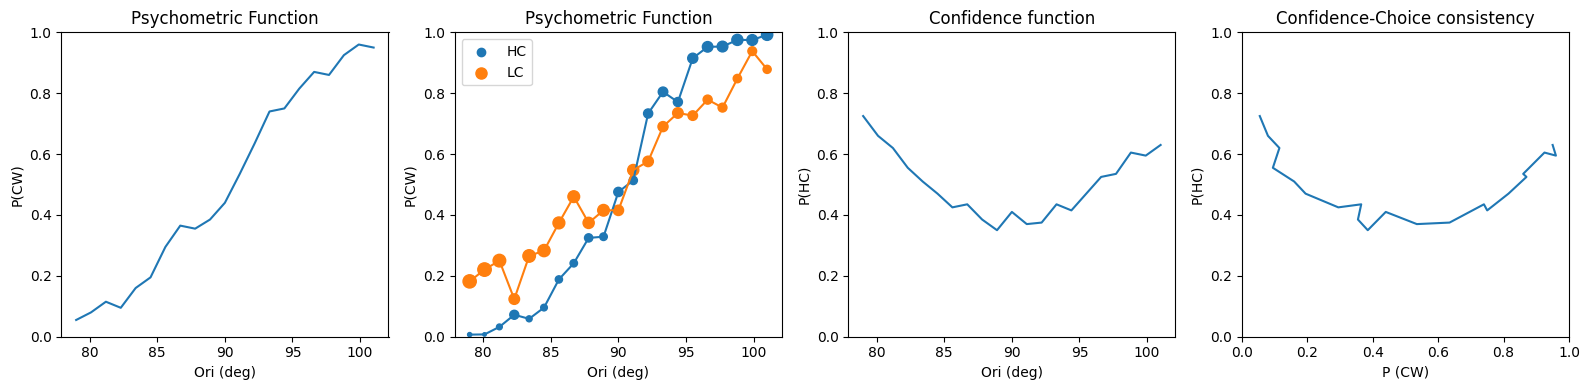

In [758]:
plt.figure(figsize=(16, 4))  # width=16 inches, height=4 inches

plt.subplot(1, 4, 1)  # 2 rows, 1 column, first subplot
plt.plot(uniqStimOris, psycFns[0, :])
plt.xlabel('Ori (deg)')
plt.ylabel('P(CW)')
plt.title('Psychometric Function')

plt.ylim([0, 1])        # y-axis limits

plt.subplot(1, 4, 2)  # second subplot
plt.scatter(uniqStimOris, psycFns[1, :], s=100*choiceCounts[0,:])
plt.scatter(uniqStimOris, psycFns[2, :], s=100*choiceCounts[1,:])
plt.plot(uniqStimOris, psycFns[1, :])
plt.plot(uniqStimOris, psycFns[2, :])
plt.xlabel('Ori (deg)')
plt.ylabel('P(CW)')
plt.title('Psychometric Function')
plt.legend(['HC', 'LC'])

plt.ylim([0, 1])        # y-axis limits

plt.subplot(1, 4, 3)  # 2 rows, 1 column, first subplot
plt.plot(uniqStimOris, confFn[0, :])
plt.xlabel('Ori (deg)')
plt.ylabel('P(HC)')
plt.title('Confidence function')

plt.ylim([0, 1])        # y-axis limits

plt.subplot(1, 4, 4)  # 2 rows, 1 column, first subplot
plt.plot(psycFns[0, :], confFn[0, :])
plt.xlabel('P (CW)')
plt.ylabel('P(HC)')
plt.title('Confidence-Choice consistency')

plt.ylim([0, 1])        # y-axis limits
plt.xlim([0, 1])        # y-axis limits

plt.tight_layout()
plt.show()


In [759]:
# sequential trial information not all at once (check standard paper in the field sequential trials, or parallel trials)
# Pick things which are convention in the field and not pick yourself
# RNN and confidence
# LC choices more likely to be CW compared to CCW for ori < 90

|z_dec| range: 0.00 to 3.13


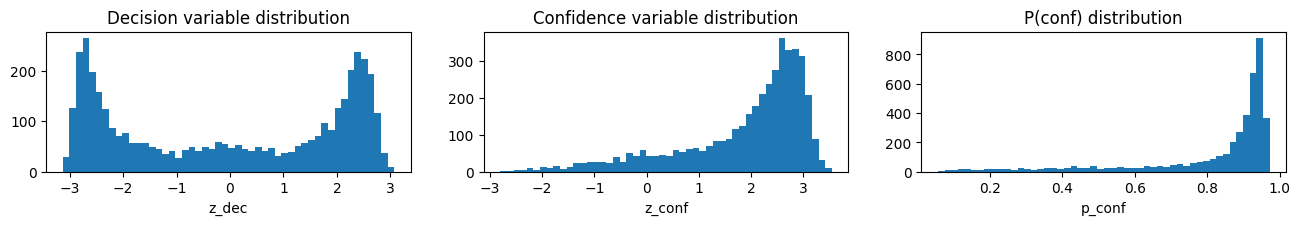

In [760]:
plt.figure(figsize=(16, 4))

# look at z_dec distribution
plt.subplot(2, 3, 1)
plt.hist(z_dec, bins=50)
plt.xlabel('z_dec')
plt.title('Decision variable distribution')

plt.subplot(2, 3, 2)
plt.hist(z_conf, bins=50)
plt.xlabel('z_conf')
plt.title('Confidence variable distribution')

plt.subplot(2, 3, 3)
plt.hist(p_conf, bins=50)
plt.xlabel('p_conf')
plt.title('P(conf) distribution')


# if all z_dec are very large magnitude e.g. |z_dec| > 5
# the signal is too clean
print(f"|z_dec| range: {np.abs(z_dec).min():.2f} to {np.abs(z_dec).max():.2f}")

In [761]:
# what are your unique orientations?
unique_ori = uniqStimOris
print(unique_ori)
print(f"Number of unique orientations: {len(unique_ori)}")

# accuracy and mean |z_dec| per orientation
print(f"\n{'Orientation':>12} | {'Accuracy':>8} | {'Mean |z_dec|':>12} | {'Mean conf':>10}")
print("-" * 50)

for ori in unique_ori:
    mask     =  tralStimVector == ori
    acc      = (choice[mask] == Y.numpy()[mask]).mean()
    z_mag    = np.abs(z_dec[mask]).mean()
    conf_mean = confidence[mask].mean()
    print(f"{ori:>12.1f} | {acc:>8.3f} | {z_mag:>12.3f} | {conf_mean:>10.3f}")

[ 79.   80.1  81.2  82.3  83.4  84.5  85.6  86.7  87.8  88.9  90.   91.1
  92.2  93.3  94.4  95.5  96.6  97.7  98.8  99.9 101. ]
Number of unique orientations: 21

 Orientation | Accuracy | Mean |z_dec| |  Mean conf
--------------------------------------------------
        79.0 |    0.945 |        2.365 |      0.887
        80.1 |    0.920 |        2.298 |      0.862
        81.2 |    0.885 |        2.230 |      0.866
        82.3 |    0.905 |        2.139 |      0.819
        83.4 |    0.840 |        1.967 |      0.817
        84.5 |    0.805 |        1.931 |      0.804
        85.6 |    0.705 |        1.873 |      0.786
        86.7 |    0.635 |        1.866 |      0.786
        87.8 |    0.645 |        1.777 |      0.774
        88.9 |    0.615 |        1.609 |      0.760
        90.0 |    0.560 |        1.812 |      0.798
        91.1 |    0.535 |        1.671 |      0.778
        92.2 |    0.635 |        1.714 |      0.780
        93.3 |    0.740 |        1.707 |      0.794
     

In [762]:
#Lawful decision - train from actual decions and then learn confidence (not biologically feasible)

Text(0.5, 1.0, 'Confidence (RNN)')

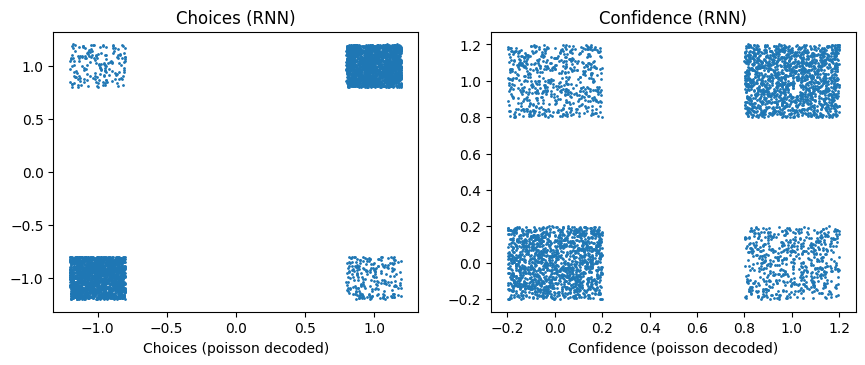

In [781]:
# ── Comparison with GT (Poisson decoded) ───────────────────────────────────────────────────────────
rnnConfidence = confidence > Cc; 
rnnDecisions  = np.where(choice == 1, 1, -1)

GTPoissonConfidence = dataTest['dataTest']['trialConfsTest']
GTPoissonDecisions  = dataTest['dataTest']['trialDecisionsTest']


plt.figure(figsize=(16, 8))

jitter = 0.2

# look at z_dec distribution
plt.subplot(2, 3, 1)
x = GTPoissonDecisions + np.random.uniform(-jitter, jitter, size=len(GTPoissonDecisions))
y = rnnDecisions + np.random.uniform(-jitter, jitter, size=len(rnnDecisions))
plt.scatter(x, y, s=1)
plt.xlabel('Choices (poisson decoded)')
plt.title('Choices (RNN)')

plt.subplot(2, 3, 2)
x = GTPoissonConfidence + np.random.uniform(-jitter, jitter, size=len(GTPoissonConfidence))
y = rnnConfidence + np.random.uniform(-jitter, jitter, size=len(rnnConfidence))
plt.scatter(x, y, s=1)
plt.xlabel('Confidence (poisson decoded)')
plt.title('Confidence (RNN)')